# TSFS12 Hand-in exercise 3: Path following for autonomous vehicles

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from vehiclecontrol import ControllerBase, SingleTrackModel, PurePursuitControllerBase
from splinepath import SplinePath
from scipy.linalg import solve_discrete_are

In [2]:
# Run if you want plots in external windows
# %matplotlib  

In [3]:
# Run the ipython magic below to activate automated import of modules. Useful if you write code in external .py files.
# %load_ext autoreload
# %autoreload 2

# Make a simple controller and simulate vehicle

In [4]:
class MiniController(ControllerBase):
    def __init__(self):
        super().__init__()
    
    def u(self, t, w):
        a = 0.0
        if t < 10:
            u = [np.pi / 180 * 10, a]
        elif 10 <= t < 20:
            u = [-np.pi / 180 * 11, a]
        elif 20 <= t < 23:
            u = [-np.pi / 180 * 0, a]
        elif 23 <= t < 40:
            u = [-np.pi / 180 * 15, a]
        else:
            u = [-np.pi / 180 * 0, a]
        return u

opts = {'L': 2, 
        'amax': np.inf,
        'amin': -np.inf,
        'steer_limit': np.pi / 3}

car = SingleTrackModel().set_attributes(opts)
car.Ts = 0.1
car.controller = MiniController()
w0 = [0, 0, 0, 2]
z0 = car.simulate(w0, T=40, dt=0.1, t0=0.0)
t, w, u = z0
M = 10
p = w[::M, 0:2]
nom_path = SplinePath(p)

Text(0.5, 1.0, 'Acceleration')

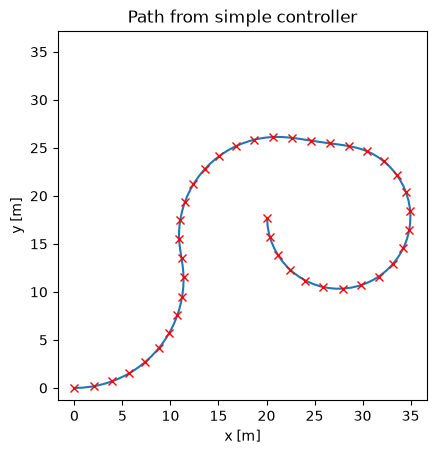

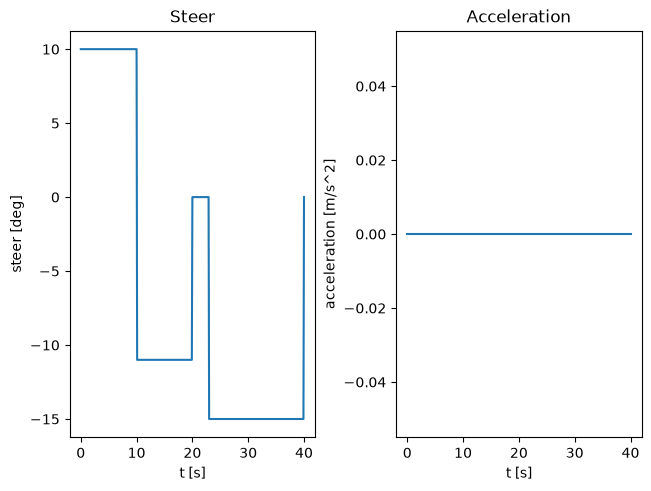

In [5]:
s = np.linspace(0, nom_path.length, 100)

_, ax = plt.subplots(num=10, clear=True)
ax.plot(nom_path.x(s), nom_path.y(s))
ax.plot(p[:, 0], p[:, 1], 'rx')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('Path from simple controller')
ax.axis('square')

fig, ax = plt.subplots(1, 2, num=11, clear=True, layout='constrained')
ax[0].plot(t, u[:, 0]*180/np.pi)
ax[0].set_xlabel('t [s]')
ax[0].set_ylabel('steer [deg]')
ax[0].set_title('Steer')

ax[1].plot(t, u[:, 1])
ax[1].set_xlabel('t [s]')
ax[1].set_ylabel('acceleration [m/s^2]')
ax[1].set_title('Acceleration')

# Pure pursuit controller

In [6]:
class PurePursuitController(PurePursuitControllerBase):
    def __init__(self, l: float, L: float, path: SplinePath = None, goal_tol: float = 1., pursuit_point_fig=None):
        """
        Create pure-pursuit controller object
        
        Input arguments:
          l -- Prediction horizon
          L -- wheel-base
          path -- SplinePath-object with the path to follow
          goal_tol -- Goal stopping tolerance (default: 1)
          pursuit_point_fig -- Figure object to illustrate pursuit-point selection (default: None)
        """
        super().__init__(pursuit_point_fig)
        self.plan = path
        self.l = l
        self.L = L
        self.goal_tol = goal_tol

        self.pursuit_idx = 0

        
    def pursuit_point(self, p_car):
        """ Return pure-pursuit given the position of the car.
        
          Input:
            p_car - Car position in global coordinates
            
          Return:
            pursuit point in global coordinates
        """

        path_points = self.plan.path
        l = self.l

        i = self.pursuit_idx

        while i < len(path_points) - 1:
            dp = path_points[i] - p_car
            distance = np.linalg.norm(dp)

            if distance >= l:
                break

            i += 1

        self.pursuit_idx = i

        p_purepursuit = path_points[i]

        return p_purepursuit
    
    def pure_pursuit_control(self, dp, theta):
        """ Compute pure-pursuit steer angle.
        
          Input:
            dp - Vector from position of car to pursuit point
            theta - heading of vehicle
          
          Output:
            return steer angle
        """


        # Unit vector in the vehicle-local x-direction
        # used in the lecture
        hx = np.array([np.sin(theta), -np.cos(theta)])

        # Local x-coordinate of pursuit point
        x = np.dot(dp, hx)

        # True squared distance to pursuit point
        l_squared = np.dot(dp, dp)

        # Pure-pursuit steering law
        delta = np.arctan(-2 * self.L * x / l_squared)

        return delta

    def u(self, t, w):
        """ Compute control action
        
          Input:
            t - current time
            w - current state w = (x, y, theta, v)
          
          Output:
            return (delta, acc) where delta is steer angle and acc acceleration
        """
        x, y, theta, v = w
        p_car = np.array([x, y])

        # Your code here to compute steering angle, use the functions
        # self.pursuit_point() and self.pure_pursuit_control() you 
        # have written above.
                # Find pursuit point
        p_purepursuit = self.pursuit_point(p_car)

        # Vector from car to pursuit point
        dp = p_purepursuit - p_car
        
        delta = self.pure_pursuit_control(dp, theta)

        #constans speed
        acc = 0

        self._pursuit_plot(p_car, p_purepursuit)  # Included for animation purposes.
        
        return np.array([delta, acc])
    
    def run(self, t, w):
        # Function that returns true until goal is reached
        p_goal = self.plan.path[-1, :]
        p_car = w[0:2]
        dp = p_car - p_goal
        dist = dp.dot(dp)        
        
        return dist > self.goal_tol**2

## Assertions

A few tests on your implementation. Note that passing these tests doesn't imply that your solution is correct but do not submit a solution if your solution doesn't pass these tests. First, test the ```pure_pursuit_control``` function

In [7]:
pp_controller = PurePursuitController(l=4, L=car.L, path=nom_path, goal_tol=0.25)
assert abs(pp_controller.pure_pursuit_control(np.array([1., 1.]), 10 * np.pi / 180) - 1.01840) < 1e-3
assert abs(pp_controller.pure_pursuit_control(np.array([1., 1.]), 30 * np.pi / 180) - 0.6319) < 1e-3
assert abs(pp_controller.pure_pursuit_control(np.array([1., 1.]), -30 * np.pi / 180) - 1.2199) < 1e-3

To ensure that the pursuit-point selection works, run a simulation with pure-pursuit illustration turned on. Requires plotting in external window.

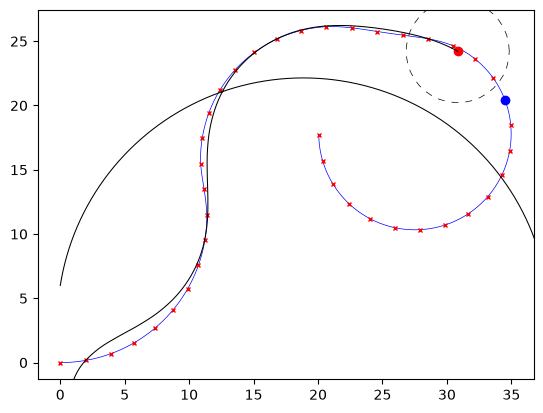

In [8]:
s = np.linspace(0, nom_path.length, 200)
fig, ax = plt.subplots(num=99, clear=True)
ax.plot(nom_path.x(s), nom_path.y(s), 'b', lw=0.5)
ax.plot(nom_path.path[:, 0], nom_path.path[:, 1], 'rx', markersize=3)

car = SingleTrackModel()
car.controller = PurePursuitController(l=4, L=car.L, path=nom_path, goal_tol=0.25, pursuit_point_fig=fig)

#ÄNDRA l & w0 HÄR


w0 = [0, 6, np.pi / 2 * 0.9, 2]
z_pp = car.simulate(w0, T=80, dt=0.1, t0=0.0)

## Simulate controller

Simulate controller without visualization

In [9]:
car = SingleTrackModel()
pp_controller = PurePursuitController(l=4, L=car.L, path=nom_path)
car.controller = pp_controller

w0 = [0, 1, np.pi / 2 * 0.9, 2]  # Sample starting state
z_pp = car.simulate(w0, T=80, dt=0.1, t0=0.0)

# State feedback controller based on the linearized path

Implement linear and non-linear state feedback control.

In [10]:
class StateFeedbackController(ControllerBase):
    def __init__(self, K: np.ndarray, L: float, path: SplinePath = None, goal_tol: float = 1.):
        super().__init__()
        self.plan = path
        self.K = np.asarray(K, dtype=float).reshape(-1)
        if self.K.shape != (2,):
            raise ValueError("K must contain two gains: [k_d, k_theta]")
        self.goal_tol = goal_tol
        self.d = []
        self.theta_e = []
        self.L = L
        self.s0 = 0

    def heading_error(self, theta, s):
        """Compute theta error
        Inputs
            theta - current heading angle
            s - projection point on path
            
        Outputs
            theta_e - heading error angle
        """
            
        tangent, _ = self.plan.heading(s)
        theta_path = np.arctan2(tangent[1], tangent[0])
        theta_e = np.arctan2(np.sin(theta - theta_path), np.cos(theta - theta_path))
        return theta_e

    def u(self, t, w):
        x, y, theta, v = w
        p_car = w[0:2]

        s, d = self.plan.project(p_car, self.s0)
        self.s0 = s
        theta_e = self.heading_error(theta, s)
        self.d.append(d)
        self.theta_e.append(theta_e)

        errors = np.array([d, theta_e])
        curvature = self.plan.c(s) - self.K @ errors    # u = u0 - K*[e_distance, e_theta]
        delta = np.arctan(self.L * curvature)           # Convert to sterring angle
        acc = 0                                         # Constant speed

        return np.array([delta, acc])
    
    def run(self, t, w):
        p_goal = self.plan.path[-1, :]
        p_car = w[0:2]
        dp = p_car - p_goal
        dist = np.sqrt(dp.dot(dp))
        
        return dist > self.goal_tol


In [11]:
class NonlinearStateFeedbackController(ControllerBase):
    def __init__(self, K: np.ndarray, L: float, path: SplinePath = None, goal_tol: float = 1.0):
        super().__init__()
        self.plan = path
        self.K = np.asarray(K, dtype=float).reshape(-1)
        if self.K.shape != (2,):
            raise ValueError("K must contain two gains: [k_d, k_theta]")
        self.goal_tol = goal_tol
        self.d = []
        self.theta_e = []
        self.L = L
        self.s0 = 0

    def heading_error(self, theta, s):
        tangent, _ = self.plan.heading(s)
        theta_path = np.arctan2(tangent[1], tangent[0])
        return np.arctan2(np.sin(theta - theta_path), np.cos(theta - theta_path))

    def u(self, t, w):
        x, y, theta, v = w
        p_car = np.array([x, y])

        s, d = self.plan.project(p_car, self.s0)
        self.s0 = s
        theta_e = self.heading_error(theta, s)
        self.d.append(d)
        self.theta_e.append(theta_e)

        if abs(theta_e) < 1e-3:
            sin_theta = 1 - theta_e**2 / 6 + theta_e**4 / 120 - theta_e**6 / 5040
        else:
            sin_theta = np.sin(theta_e) / theta_e

        nonlinear_errors = np.array([sin_theta * d, theta_e])
        curvature = self.plan.c(s) - self.K @ nonlinear_errors
        delta = np.arctan(self.L * curvature)
        acc = 0.0
        return np.array([delta, acc])

    def run(self, t, w):
        p_goal = self.plan.path[-1, :]
        p_car = w[0:2]
        dp = p_car - p_goal
        return np.sqrt(dp.dot(dp)) > self.goal_tol


In [12]:
def compute_lqr(Q, R, L: float, v_ref: float, Ts: float = 0.1):
    A = np.array([
        [0.0, v_ref],
        [0.0, 0.0],
    ])

    B = np.array([
        [0.0],
        [v_ref],
    ])

    # Discrete time steps
    Ad = np.eye(2) + Ts * A
    Bd = Ts * B

    # Solve Riccati equation and return LQR gain.
    P = solve_discrete_are(Ad, Bd, Q, R)
    K_lqr = np.linalg.solve(
        R + Bd.T @ P @ Bd,
        Bd.T @ P @ Ad,
    ).reshape(-1)

    return K_lqr

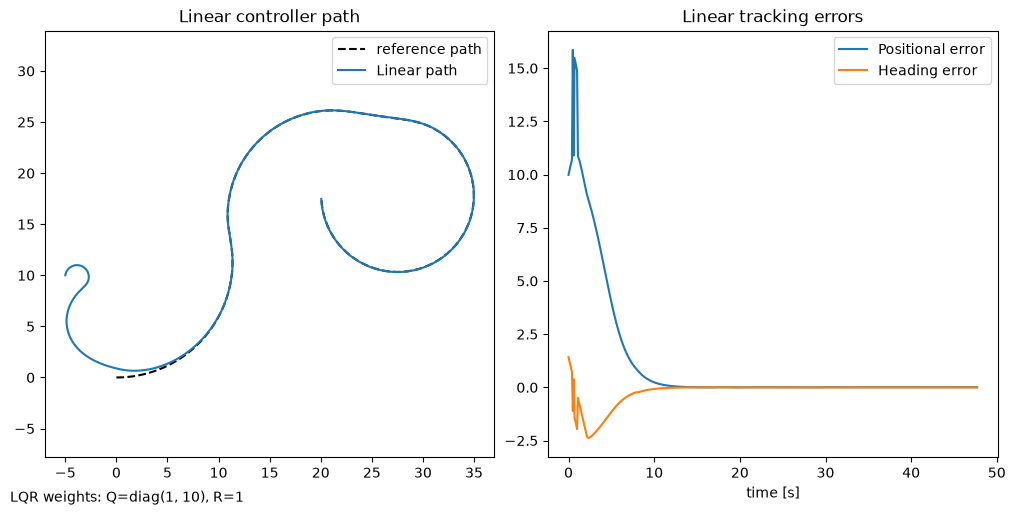

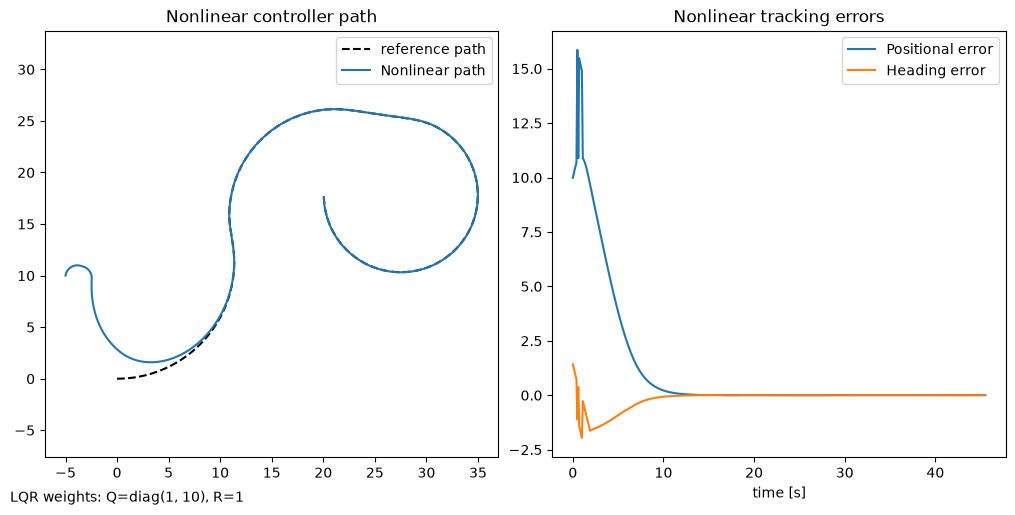

In [13]:
w0_sf = [-5, 10, 0.9 * np.pi / 2, 2]

Q = np.diag([1.0, 10.0])  # costs for d and theta_e
R = np.array([[1.0]])     # input cost
L = SingleTrackModel().L
K_lqr = compute_lqr(Q, R, L=L, v_ref=w0_sf[3])


def simulate_and_plot_controller(controller_class, label, figure_num):
    """Simulate one controller and make its original two-panel plot."""
    car = SingleTrackModel()
    controller = controller_class(K=K_lqr, L=car.L, path=nom_path, goal_tol=0.25)
    car.controller = controller
    t, w, u = car.simulate(w0_sf, T=80, dt=0.1)

    fig, ax = plt.subplots(
        1, 2, num=figure_num, clear=True, layout="constrained", figsize=(10, 5)
    )
    fig.text(
        0, 0,
        f"LQR weights: Q=diag({Q[0, 0]:g}, {Q[1, 1]:g}), R={R[0, 0]:g}",
        ha="left", va="bottom",
    )
    s_ref = np.linspace(0, nom_path.length, 300)
    ax[0].plot(nom_path.x(s_ref), nom_path.y(s_ref), "k--", label="reference path")
    ax[0].plot(w[:, 0], w[:, 1], label=f"{label} path")
    ax[0].axis("equal")
    ax[0].legend()
    ax[0].set_title(f"{label} controller path")

    ax[1].plot(t, controller.d, label="Positional error")
    ax[1].plot(t, controller.theta_e, label="Heading error")
    ax[1].legend()
    ax[1].set_xlabel("time [s]")
    ax[1].set_title(f"{label} tracking errors")

    return t, w, u, controller, fig, ax


linear_result = simulate_and_plot_controller(
    StateFeedbackController, "Linear", figure_num=12
)
nonlinear_result = simulate_and_plot_controller(
    NonlinearStateFeedbackController, "Nonlinear", figure_num=13
)
